<a href="https://colab.research.google.com/github/Hrishib80/iHub-Assignments/blob/main/Module1_Lab1_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.datasets import mnist

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
(train_X, train_y), (test_X, test_y) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
no7 = train_X[train_y == 7, :, :]
no8 = train_X[train_y == 8, :, :]

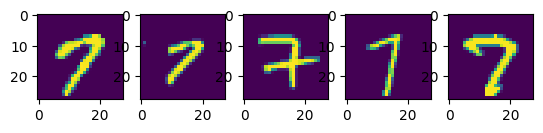

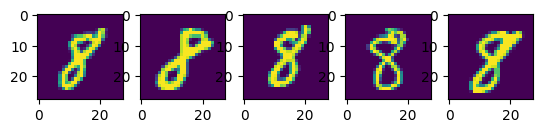

In [ ]:
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no7[ii,:,:])
plt.show()
for ii in range(5):
  plt.subplot(1, 5, ii+1)
  plt.imshow(no8[ii,:,:])
plt.show()

In [ ]:
sum7 = np.sum(no7>0, (1,2))
sum8 = np.sum(no8>0, (1,2))

(array([  58.,  505., 1325., 1769., 1236.,  645.,  233.,   65.,   12.,
           3.]),
 array([ 84. , 108.3, 132.6, 156.9, 181.2, 205.5, 229.8, 254.1, 278.4,
        302.7, 327. ]),
 <BarContainer object of 10 artists>)

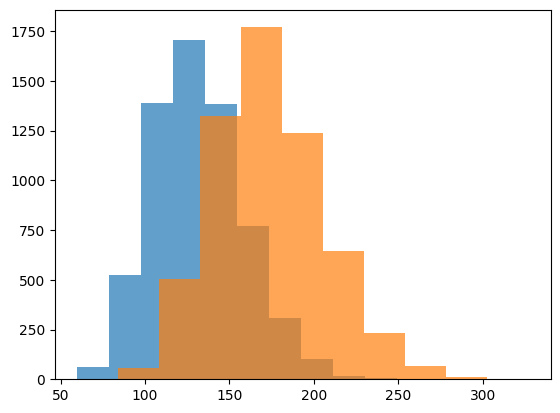

In [ ]:
plt.hist(sum7, alpha = 0.7, label = '7')
plt.hist(sum8, alpha = 0.7, label = '9')

Lot's of similarity!

In [ ]:
def cumArr(img):
  img2 = img.copy()
  for i in range(1, img.shape[0]):
    img2[i, :] = img2[i, :] + img2[i-1, :]
  img2 = img2 > 0
  return img2

def getHolePixels(img):
  img1 = cumArr(img)
  img2 = np.rot90(cumArr(np.rot90(img,1)), -1)
  img3 = np.rot90(cumArr(np.rot90(img,2)), -2)
  img4 = np.rot90(cumArr(np.rot90(img,-1)), 1)
  hull = img1 & img2 & img3 & img4
  hole = hull & ~(img>0)
  return hole

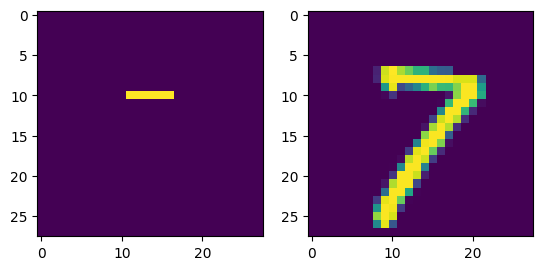

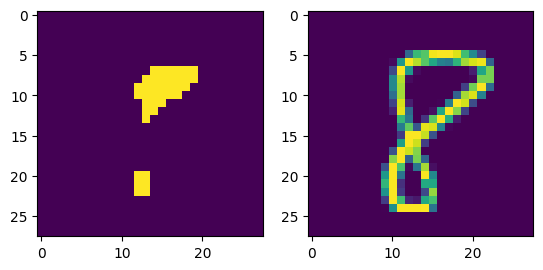

In [ ]:
imgs = [no7[2004,:,:],  no8[3045,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHolePixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

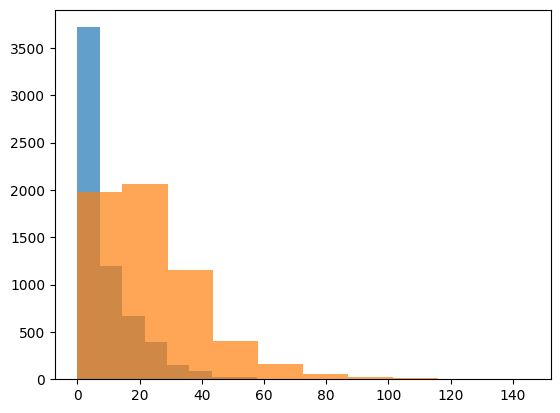

In [ ]:
hole7 = np.array([getHolePixels(i).sum() for i in no7])
hole8 = np.array([getHolePixels(i).sum() for i in no8])

plt.hist(hole7, alpha=0.7);
plt.hist(hole8, alpha=0.7);

In [ ]:
def getHullPixels(img):
  img1 = cumArr(img)
  img2 = np.rot90(cumArr(np.rot90(img,1)), -1)
  img3 = np.rot90(cumArr(np.rot90(img,2)), -2)
  img4 = np.rot90(cumArr(np.rot90(img,-1)), 1)
  hull = img1 & img2 & img3 & img4
  return hull

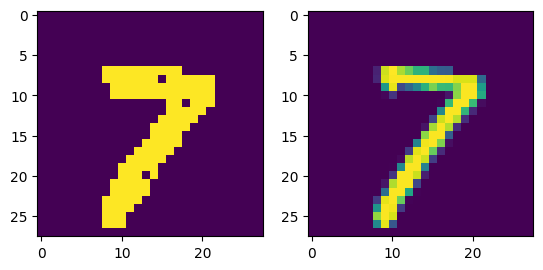

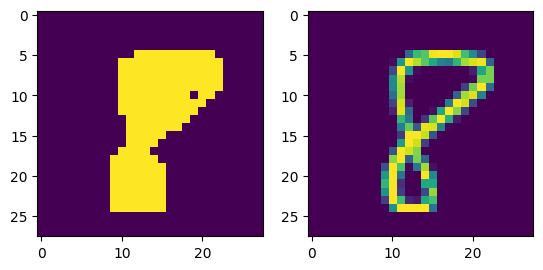

In [ ]:
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHullPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

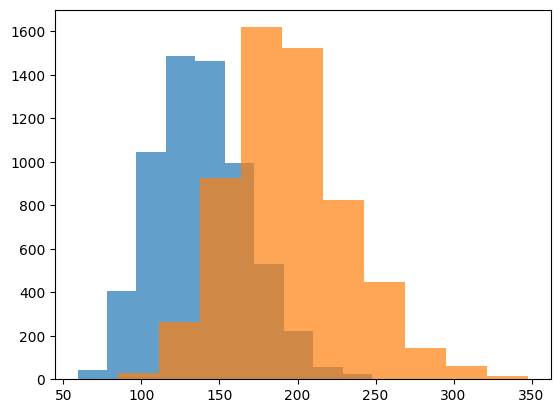

In [ ]:
hull7 = np.array([getHullPixels(i).sum() for i in no7])
hull8 = np.array([getHullPixels(i).sum() for i in no8])

plt.hist(hull7, alpha=0.7);
plt.hist(hull8, alpha=0.7);

In [ ]:
def minus(a, b):
  return a & ~ b

def getBoundaryPixels(img):
  img = img.copy()>0  # binarize the image
  rshift = np.roll(img, 1, 1)
  lshift = np.roll(img, -1 ,1)
  ushift = np.roll(img, -1, 0)
  dshift = np.roll(img, 1, 0)
  boundary = minus(img, rshift) | minus(img, lshift) | minus(img, ushift) | minus(img, dshift)
  return boundary

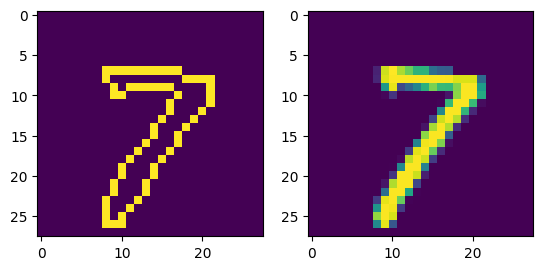

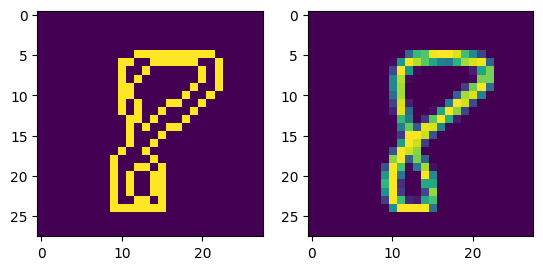

In [ ]:
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getBoundaryPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

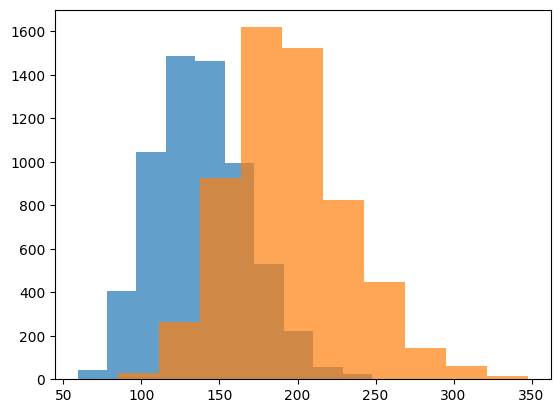

In [ ]:
bound7 = np.array([getHullPixels(i).sum() for i in no7])
bound8 = np.array([getHullPixels(i).sum() for i in no8])

plt.hist(bound7, alpha=0.7);
plt.hist(bound8, alpha=0.7);

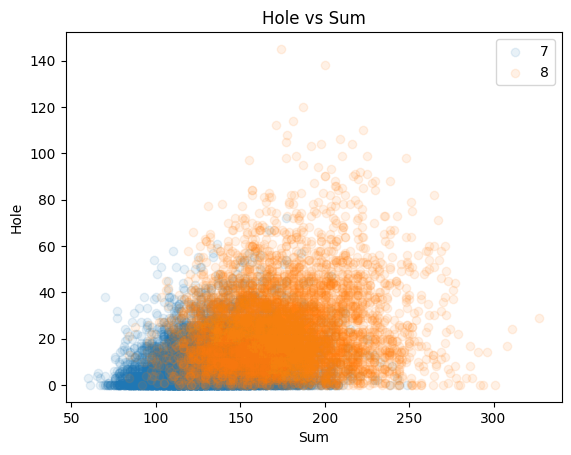

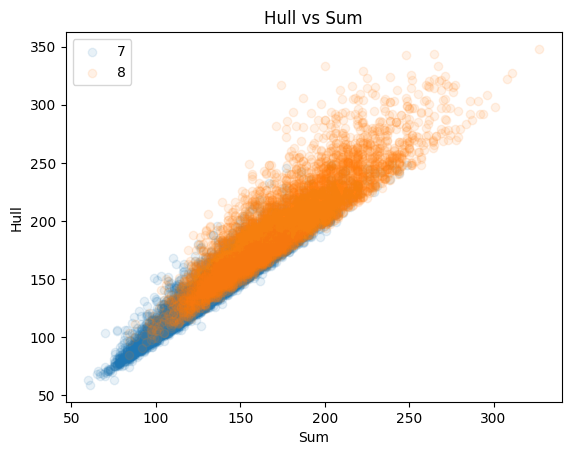

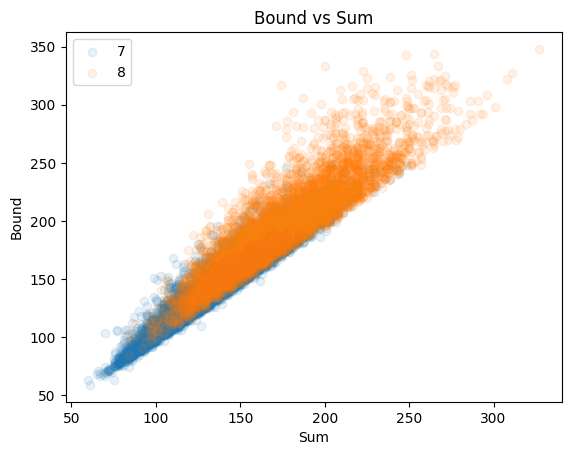

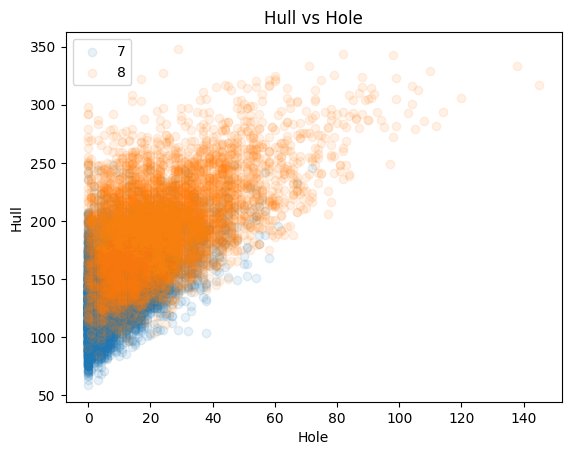

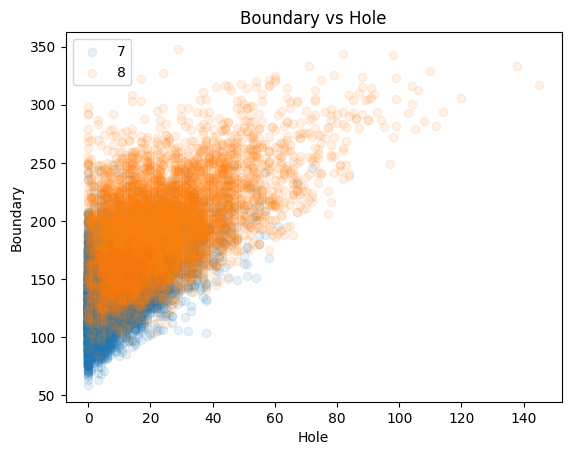

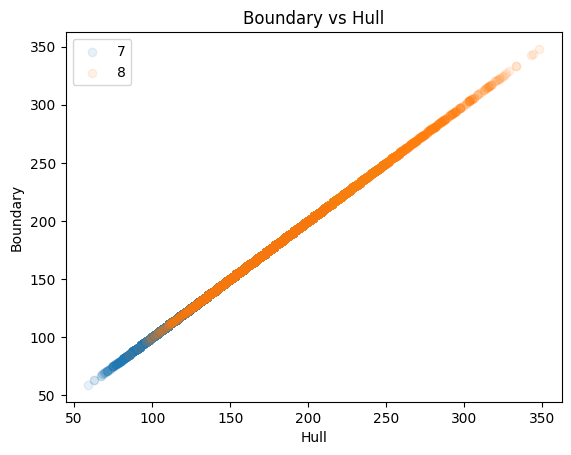

In [ ]:
def plot_feature_comparison(feature1_7, feature2_7, feature1_8, feature2_8, feature1_name, feature2_name):
    plt.scatter(feature1_7, feature2_7, alpha=0.1, label='7')
    plt.scatter(feature1_8, feature2_8, alpha=0.1, label='8')
    plt.xlabel(feature1_name)
    plt.ylabel(feature2_name)
    plt.legend()
    plt.title(f'{feature2_name} vs {feature1_name}')
    plt.show()

# Sum and hole
plot_feature_comparison(sum7, hole7, sum8, hole8, 'Sum', 'Hole')

# Sum and hull
plot_feature_comparison(sum7, hull7, sum8, hull8, 'Sum', 'Hull')

# Sum and bound
plot_feature_comparison(sum7, bound7, sum8, bound8, 'Sum', 'Bound')

# Hole and Hull
plot_feature_comparison(hole7, hull7, hole8, hull8, 'Hole', 'Hull')

# Hole and boundary
plot_feature_comparison(hole7, bound7, hole8, bound8, 'Hole', 'Boundary')

# Hull and boundary
plot_feature_comparison(hull7, bound7, hull8, bound8, 'Hull', 'Boundary')

In [ ]:
cl7 = ['class 7']*len(sum7)
cl8 = ['class 8']*len(sum8)
df = pd.DataFrame(list(zip(np.concatenate((hole7, hole8)), np.concatenate((sum7,sum8)),
                           np.concatenate((bound7,bound8)), np.concatenate((cl7, cl8)))),
               columns =['Hole', 'Sum', 'Boundary', 'Class'])
df.head()
fig = px.scatter_3d(df, x='Hole', y='Sum', z='Boundary', color='Class', opacity=0.1)
fig.show()

New method to distinguish -> Only consider the horizontal second half of the image (the problem would be similar to classifying 0 and 1 where the boundary image would be best

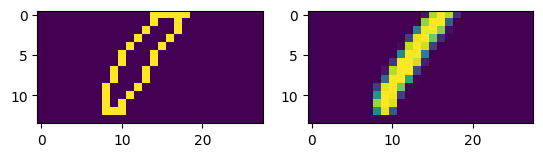

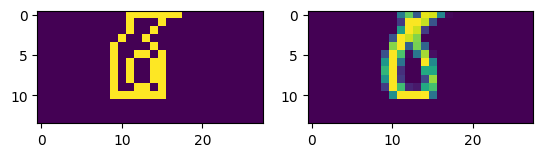

In [ ]:
no7_half = train_X[train_y == 7, int(no7.shape[1]/2):, :]
no8_half = train_X[train_y == 8, int(no8.shape[1]/2):, :]
images = [no7_half[2004,:,:],  no8_half[3045,:,:]]
for img in images:
  plt.subplot(1,2,1)
  plt.imshow(getBoundaryPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

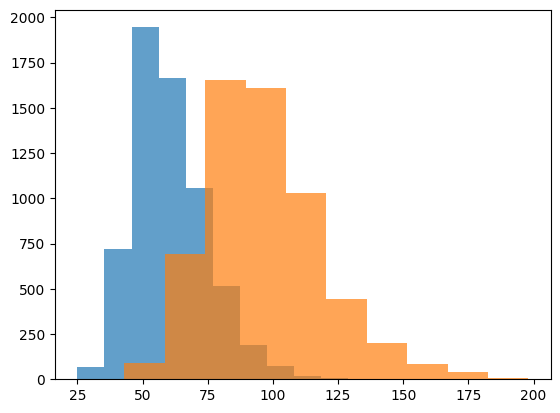

In [ ]:
bound_half7 = np.array([getHullPixels(i).sum() for i in no7_half])
bound_half8 = np.array([getHullPixels(i).sum() for i in no8_half])

plt.hist(bound_half7, alpha=0.7);
plt.hist(bound_half8, alpha=0.7);

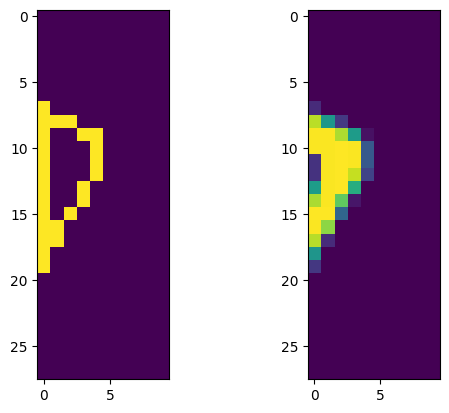

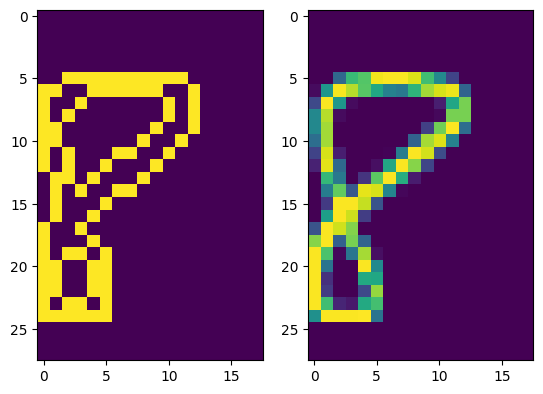

In [ ]:
no7_half = train_X[train_y == 7, :int(3*no7.shape[0]/4), 18:]
no8_half = train_X[train_y == 8, :int(3*no8.shape[0]/4), 10:]
images = [no7_half[4,:,:],  no8_half[3045,:,:]]
for img in images:
  plt.subplot(1,2,1)
  plt.imshow(getBoundaryPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

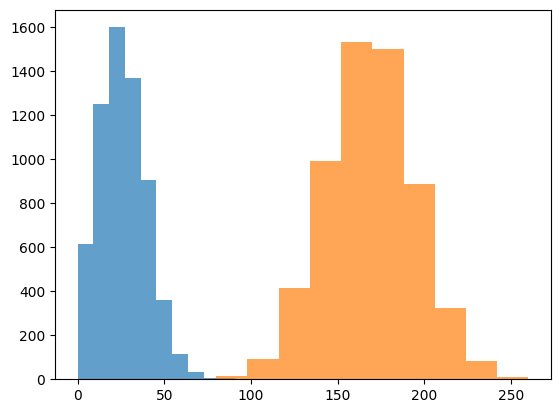

In [ ]:
bound_half7 = np.array([getHullPixels(i).sum() for i in no7_half])
bound_half8 = np.array([getHullPixels(i).sum() for i in no8_half])

plt.hist(bound_half7, alpha=0.7);
plt.hist(bound_half8, alpha=0.7);

Here, specific parts of the of the image is used to differenentite, also this can't be generailsed for all numbers, it works for 7 and 8